# PROJECT CODE

**note:** Clicking "Run All" in this notebook will initiate every training call to every different version of the model I tried. This would take several hours. I recommend stepping through the notebook manually and running relevant parts if desired.

All the training runs take a very long time (> 1 hour). To see a sample of how training works, navigate to the training tab and run the cell under "Example Training." This will only run 3 epochs of training and should only take a few minutes.

# Setup


### Install Ultralytics (Required)

In [2]:
%pip install ultralytics roboflow

import ultralytics
ultralytics.checks()

Ultralytics 8.3.239 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)
Setup complete ✅ (12 CPUs, 53.0 GB RAM, 38.7/235.7 GB disk)


### Download datasets

In order to train, run one of the cells below to import a dataset. Note that each cell runs such that the path of the downloaded dataset is the same. Therefore, when executing a training run, the only dataset used will be the one most recently downloaded and saved via running one of these cells.

Run to import my modified datset WITH cleaned examples (most recent -- recommended)

In [18]:
from roboflow import Roboflow

# NOTE 1 - Running this cell should take about 1 minute

# NOTE 2 - running this section requires the user to have a Roboflow private API key
# API Keys can be obtained for free by signing up for an account at https://universe.roboflow.com/
# I will be hiding my API key from this submission
private_api_key = "YOUR_API_KEY"
rf = Roboflow(api_key=private_api_key)

# download dataset from Roboflow
project = rf.workspace("lukes-workspace-gqbsx").project("trash-detect-tuqrs-ilfqe")
dataset = project.version(9).download("yolov8")

print(f"Data ready at: {dataset.location}")

loading Roboflow workspace...
loading Roboflow project...
Exporting format yolov8 in progress : 85.0%
Version export complete for yolov8 format



Extracting Dataset Version Zip to trash-detect-9 in yolov8:: 100%|██████████| 7278/7278 [00:03<00:00, 2153.81it/s]

Data ready at: /content/trash-detect-9


Run to import my modified datset without cleaned examples

In [ ]:
from roboflow import Roboflow

# NOTE 1 - Running this cell should take about 1 minute

# NOTE 2 - running this section requires the user to have a Roboflow private API key
# API Keys can be obtained for free by signing up for an account at https://universe.roboflow.com/
# I will be hiding my API key from this submission
private_api_key = "YOUR_API_KEY"
rf = Roboflow(api_key=private_api_key)

# download dataset from Roboflow
project = rf.workspace("lukes-workspace-gqbsx").project("trash-detect-tuqrs-ilfqe")
dataset = project.version(8).download("yolov8")

print(f"Data ready at: {dataset.location}")

Run to import default dataset (none of the project-specific data)

In [ ]:
from roboflow import Roboflow

# NOTE 1 - Running this cell should take about 1 minute

# NOTE 2 - running this section requires the user to have a Roboflow private API key
# API Keys can be obtained for free by signing up for an account at https://universe.roboflow.com/
# I will be hiding my API key from this submission
private_api_key = "YOUR_API_KEY"
rf = Roboflow(api_key=private_api_key)

# download dataset from Roboflow
project = rf.workspace("dune-eg9na").project("trash-detect-tuqrs")
dataset-initial = project.version(2).download("yolov8")

print(f"Data ready at: {dataset.location}")

Sanity Check - did we actually import the data?

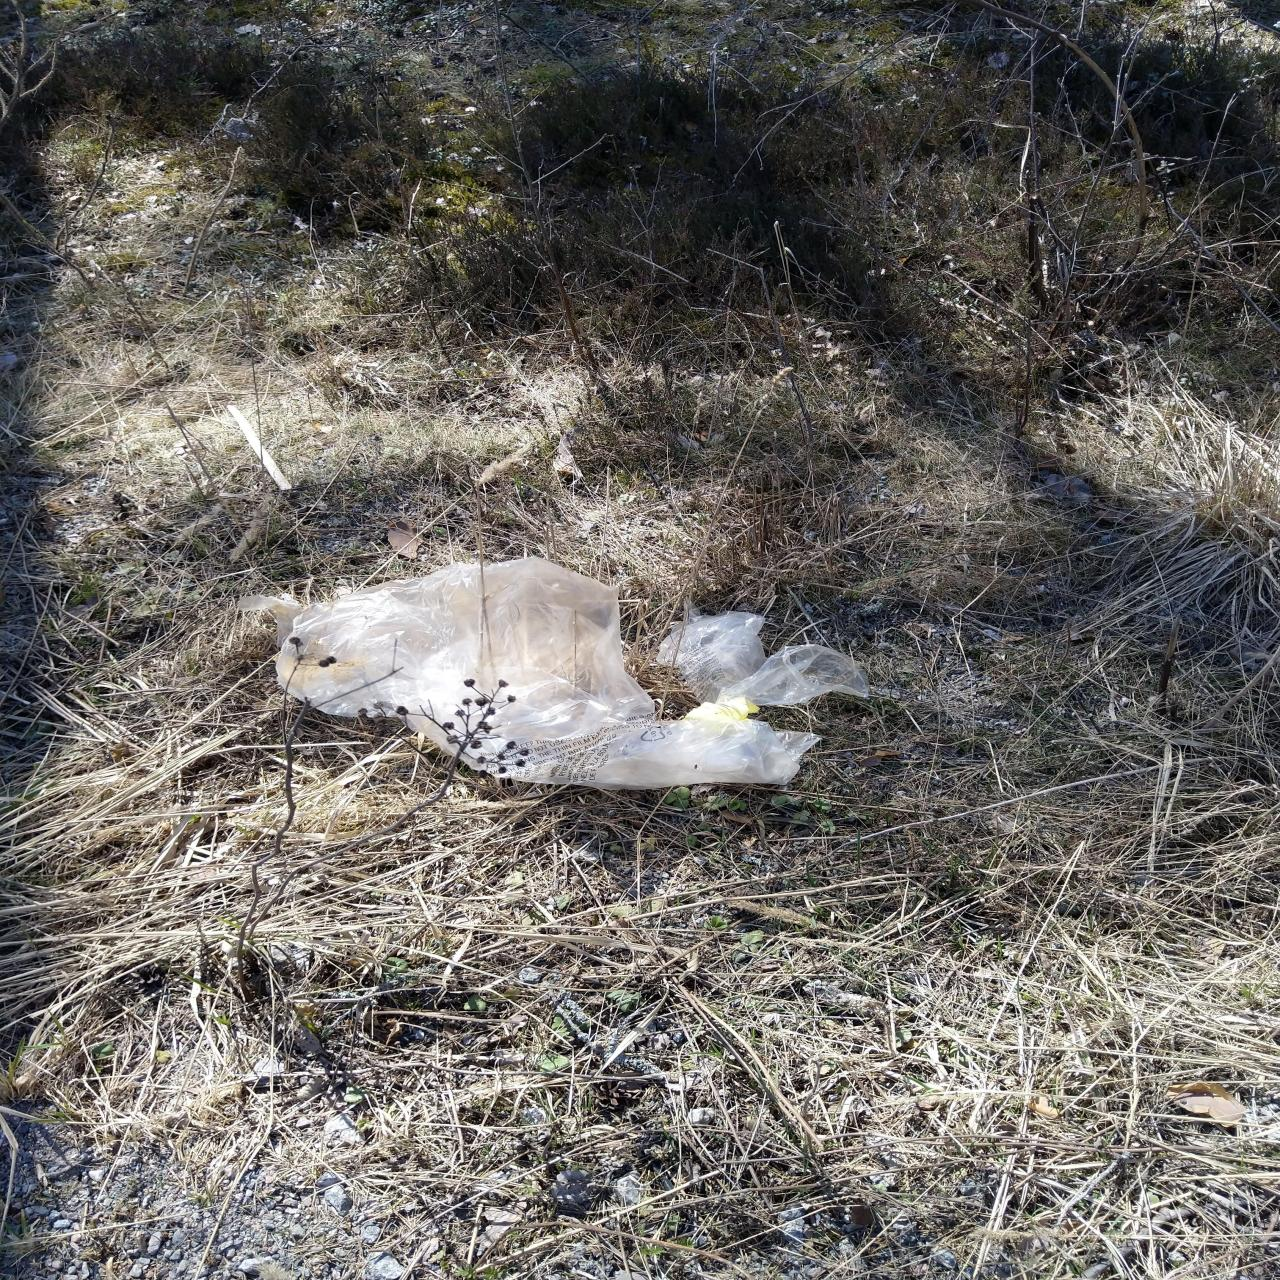

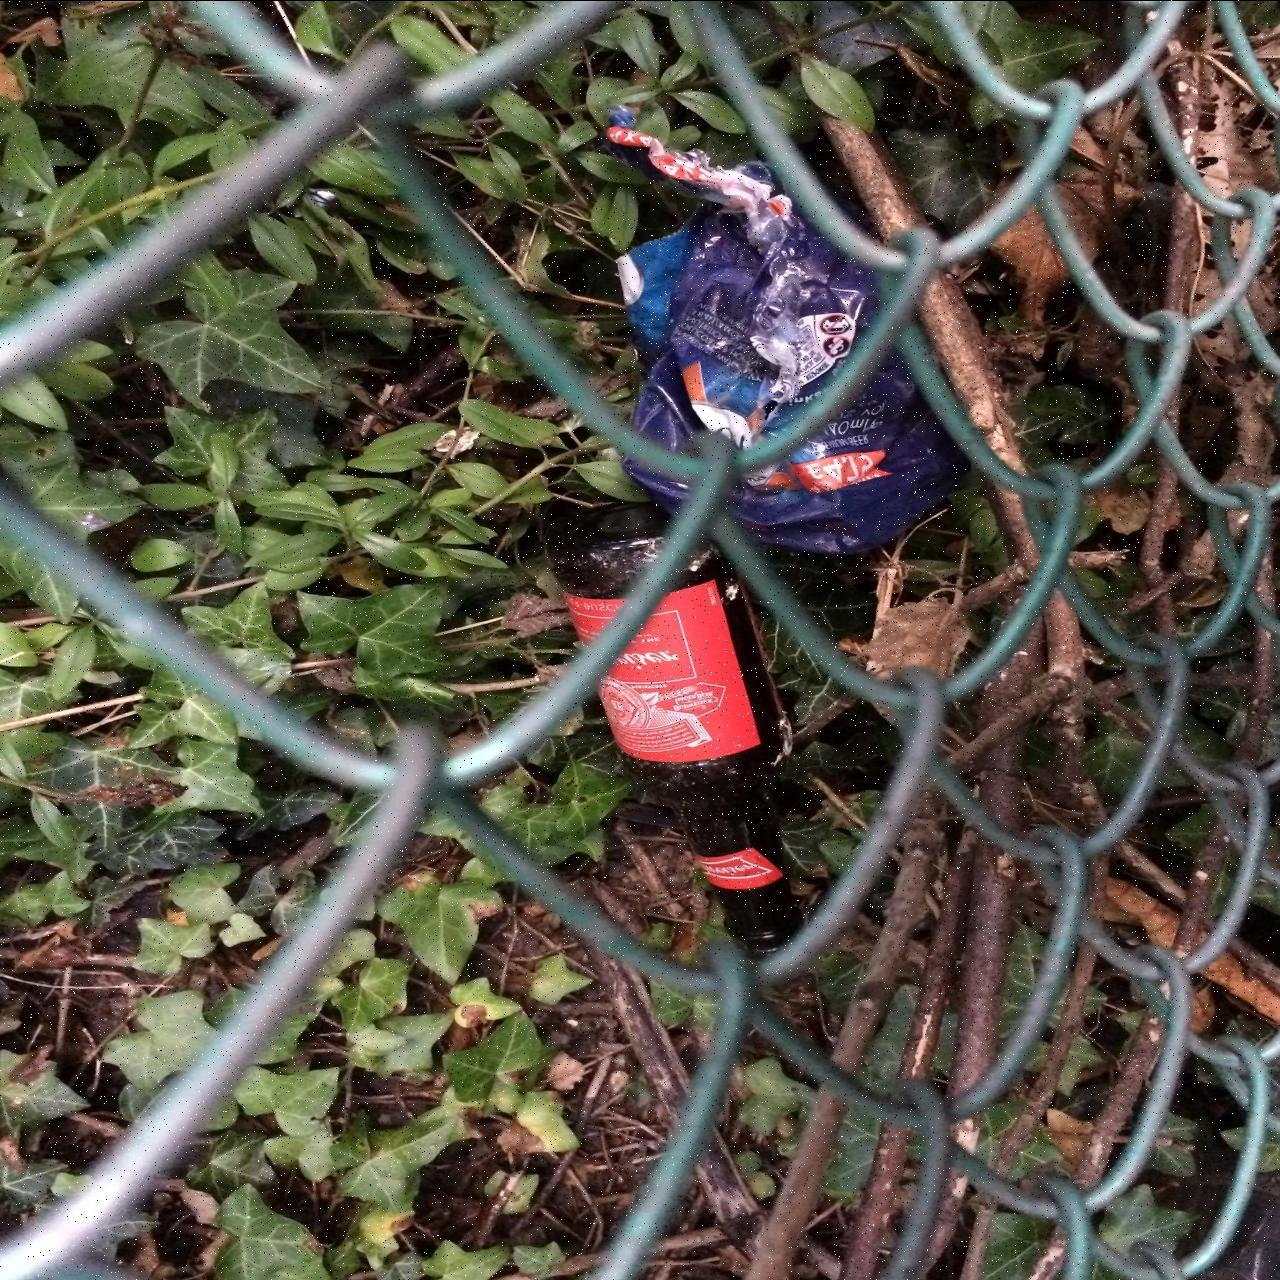

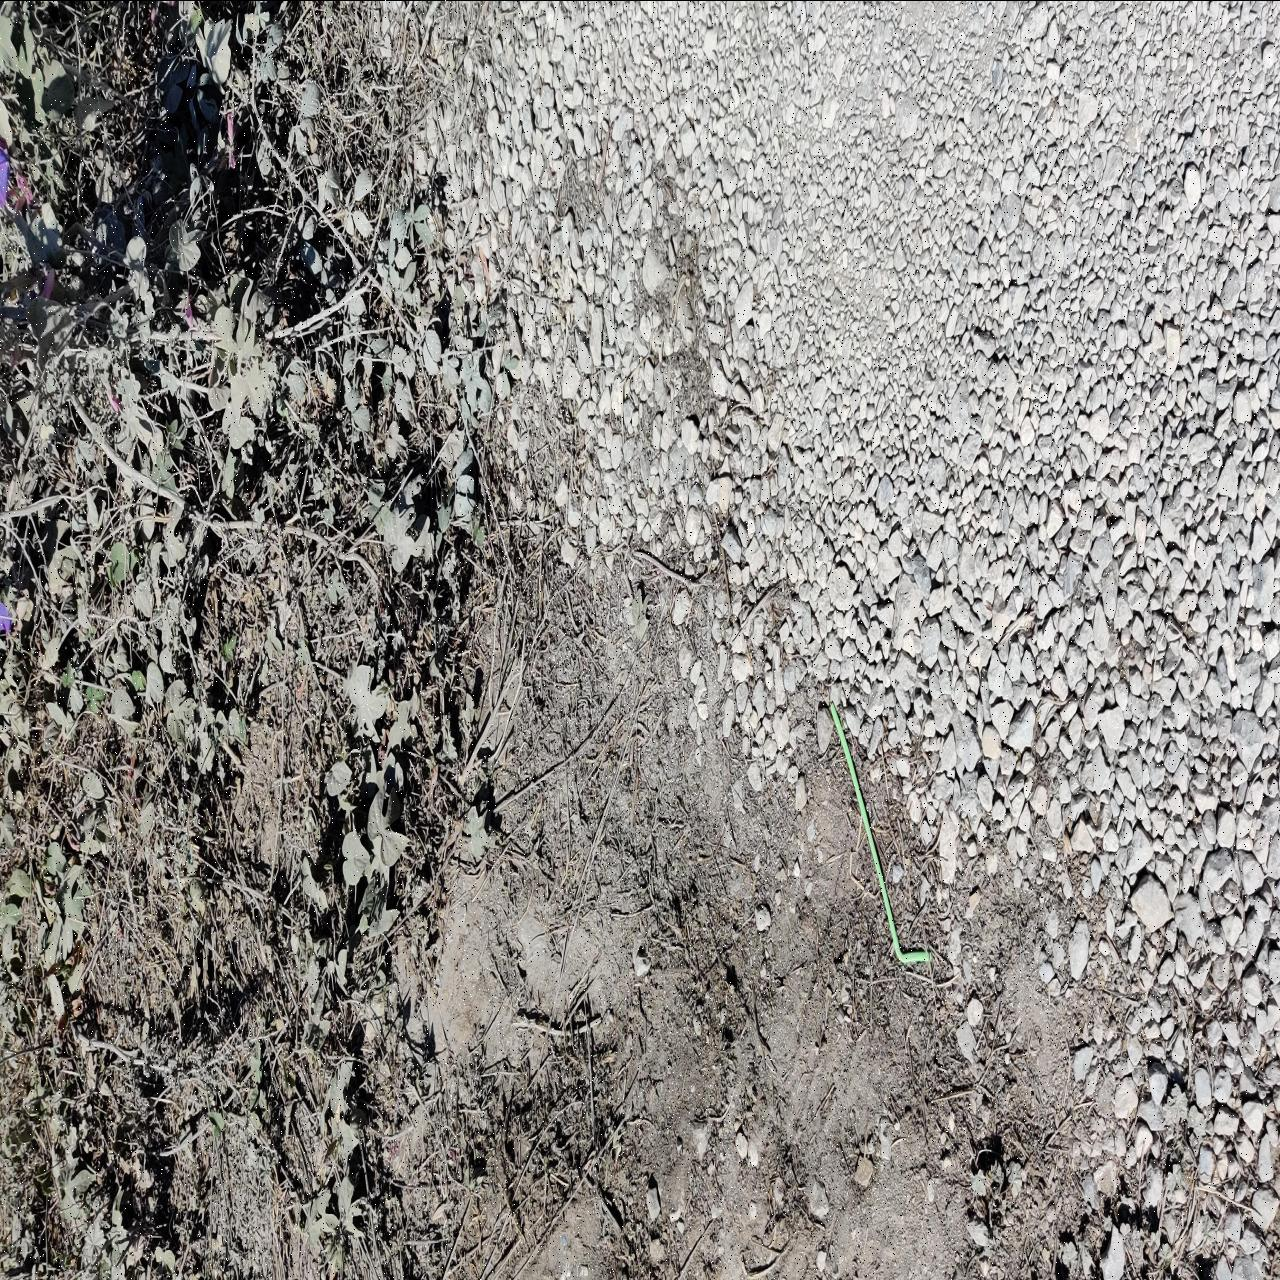

In [16]:
import glob
import random
from IPython.display import Image, display

# show 3 random images from the training set to ensure it downloaded correctly
image_files = glob.glob(f"{dataset.location}/train/images/*.jpg")
a = random.randint(0, 3630)
for img in image_files[a :(a + 3)]:
    display(Image(filename=img, width=400))

# Training

**Note 1:** Summary reports appear by default at the end of training. Tables with summary data are produced in the project report.

**Note 2:** With the exception of the example training block, all 3 of these cells produce the same output--that is, each block will run a training routine on whichever dataset you imported above in the setup block. They are here in the notebook because it was easier to compare them when I could just scroll back and forth to view their respective output tables. While I was working on the project, I would import a dataset, train, import second dataset, train in different block, etc.

Base Training

In [6]:
from ultralytics import YOLO

# load the model
model = YOLO('yolov8m.pt')  # 'm' = medium. Change to 's' or 'n' for better speed.

# train
results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    project="park_litter_project",
    name="medium-50-epochs-final"
)

Ultralytics 8.3.239 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/trash-detect-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=medium-50-epochs-final, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=

Training on Updated Hyperparams

In [17]:
from ultralytics import YOLO

# load model
model = YOLO('yolov8m.pt')  # 'm' = medium. Change to 's' or 'n' for better speed.

# train
results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=60,
    imgsz=1280,
    batch=8,
    project="park_litter_project",
    name="medium-100e-1280px-frozen10",

    freeze=10,              # freeze the first 10 layers (0-9) of the backbone
    optimizer='AdamW',      # use AdamW optimizer instead of SGD
    cos_lr=True,            # use Cosine Learning Rate
    lr0=0.001,              # adjust learning rate to compensate for AdamW aggressiveness
    close_mosaic=10,        # remove mosaic images from
)

Ultralytics 8.3.239 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/trash-detect-8/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=medium-100e-1280px-frozen10, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=100, perspect

Training on Updated Hyperparams With 200 Cleaned Exs. (Best Model)

In [19]:
from ultralytics import YOLO

# load model
model = YOLO('yolov8m.pt')  # 'm' = medium. Change to 's' or 'n' for better speed.

# train
results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=20,
    imgsz=1280,
    batch=8,
    project="park_litter_project",
    name="medium-100e-1280px-frozen10-cleaned1",

    freeze=10,              # freeze the first 10 layers (0-9) of the backbone
    optimizer='AdamW',      # use AdamW optimizer instead of SGD
    cos_lr=True,            # use Cosine Learning Rate
    lr0=0.001,              # adjust learning rate to compensate for AdamW aggressiveness
    close_mosaic=10,        # remove mosaic images from the final 10 epochs
)

Ultralytics 8.3.239 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/trash-detect-9/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=medium-100e-1280px-frozen10-cleaned1, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=100,

Example Training

In [ ]:
from ultralytics import YOLO

# load model
model = YOLO('yolov8m.pt')  # 'm' = medium. Change to 's' or 'n' for better speed.

# train
results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=3,
    imgsz=1280,
    batch=8,
    project="park_litter_project",
    name="medium-100e-1280px-frozen10-cleaned1",

    freeze=10,              # freeze the first 10 layers (0-9) of the backbone
    optimizer='AdamW',      # use AdamW optimizer instead of SGD
    cos_lr=True,            # use Cosine Learning Rate
    lr0=0.001,              # adjust learning rate to compensate for AdamW aggressiveness
    close_mosaic=10,        # remove mosaic images from the final 10 epochs
)

# Outputs

The code in this cell produces labeled outputs from the validation set. These outputs are reproduced in the project report.

Here is what the model detected on the validation set:


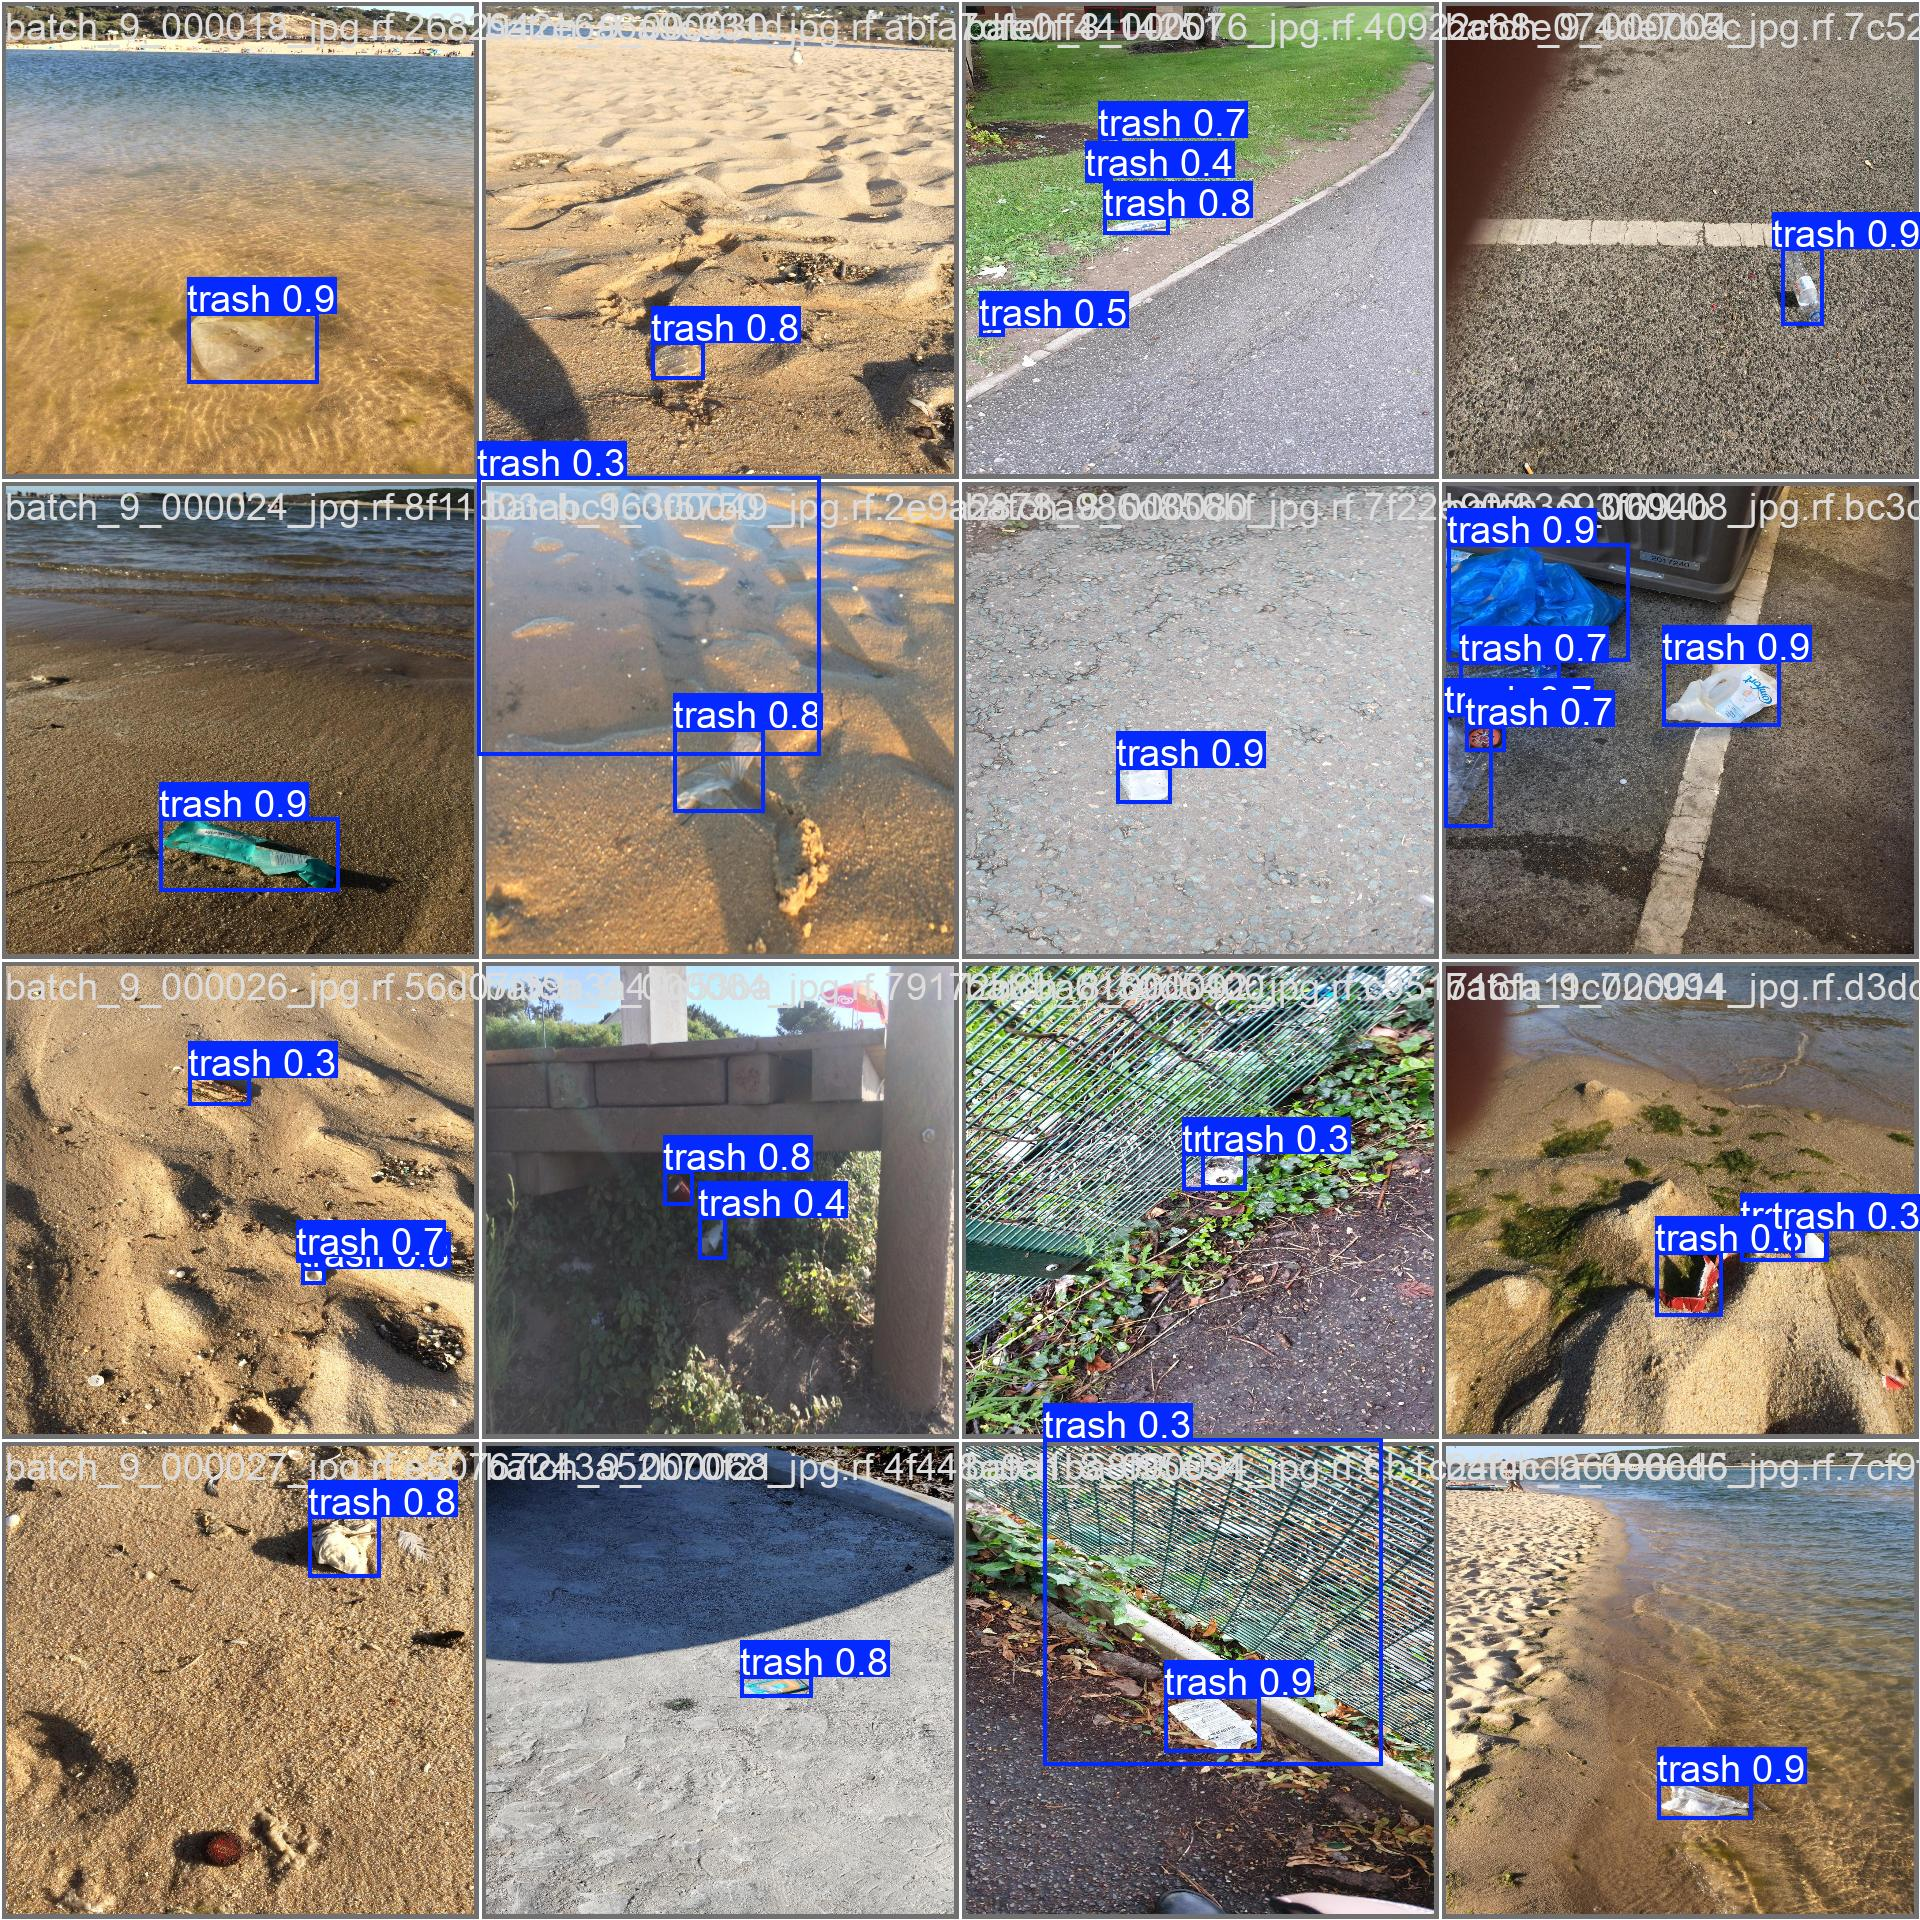

In [20]:
from IPython.display import Image, display
import os

# find the validation prediction image from run
val_img_path = f"park_litter_project/medium-100e-1280px-frozen10-cleaned1/val_batch0_pred.jpg"

# check if it exists and display it
if os.path.exists(val_img_path):
    print("Here is what the model detected on the validation set:")
    display(Image(filename=val_img_path, width=800))
else:
    print("Image not found yet. Did training finish?")

# Model Save

In [23]:
from google.colab import files

# download the best version of the model
files.download('park_litter_project/medium-100e-1280px-frozen10/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>